<a href="https://colab.research.google.com/github/abeerahb/basic-workshop-/blob/main/Part_2___Intro_to_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###_B9 Network Neuroscience and AI : Python, Machine Learning and AI Workshop_

#Part 2: Introduction to Machine Learning

In this part we will learn how to train and test two different ML models on the MNIST handwritten digit dataset using the sklearn library.

In [3]:
# First import numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

## MNIST dataset

The MNIST dataset is a collection of handwritten digit images used extensively in machine learning for training and benchmarking image classification algorithms, particularly neural networks.

In [4]:
# Next lets import the dataset we want to work with
# Today we'll use a smaller version of the MNIST dataset just to practice with (less images, 8x8 instead of 28x28)
from sklearn.datasets import load_digits
digits = load_digits()

In [5]:
digits.data.shape

(1797, 64)

In [6]:
digits.data[0].shape

(64,)

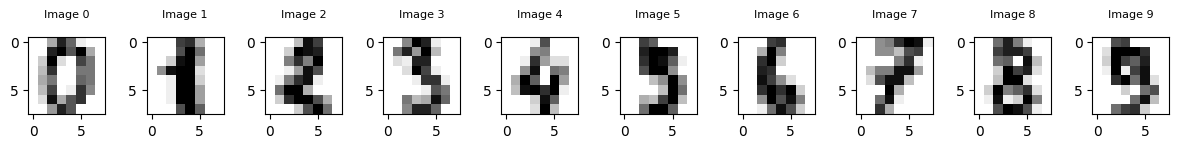

In [7]:
# Plotting the image data
# Note: The digits.data is a 64-element linear array representing an 8x8 image.
# We need to reshape it to (8,8) for correct visualization.
plt.figure(figsize=(15,1))
for index, (image, label) in enumerate(zip(digits.data[0:10],
                                           digits.target[0:10])):
    plt.subplot(1, 10, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.binary)
    plt.title('Image %i\n' % label, fontsize = 8);

## Train-test split

In machine learning, a train-test split separates data into training and testing sets. We train the model on the training set and evaluate the model's performance on the unseen test data, preventing overfitting and providing an unbiased assessment of the model's generalization ability.

In [8]:
# Split the data into train and test sets
# We'll set the percentage of images in the test set using the test_size argument.
# `train_test_split` returns four arrays: X_train, X_test, y_train, y_test.
# X_train: features for training, X_test: features for testing.
# y_train: labels for training, y_test: labels for testing.
# `test_size=0.25`: Allocates 25% of the data to the test set and 75% for training.
# `random_state=0`: Ensures reproducibility; running the code multiple times with this will produce the same split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                   test_size=0.25,
                                                   random_state=0)

In [9]:
X_train.shape

(1347, 64)

In [10]:
X_test.shape

(450, 64)

##Logistic regression

Logistic regression is a statistical method for multi-class classification that predicts the probability of an instance belonging to a particular class by transforming a linear combination of features using the sigmoid function.

See sklearn documentation at:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html



In [11]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(fit_intercept=True, penalty='l2', max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Score on the training set
logreg_train_score = clf.score(X_train, y_train)
print(logreg_train_score)

1.0


In [13]:
print("Logistic Regression Coefficients (clf.coef_):\n", clf.coef_)
print("\nLogistic Regression Intercept (clf.intercept_):\n", clf.intercept_)
print("\nLogistic Regression Classes (clf.classes_):\n", clf.classes_)

Logistic Regression Coefficients (clf.coef_):
 [[ 0.00000000e+00 -2.78233457e-03 -3.25876253e-02  7.37969225e-02
   6.53273186e-02 -1.07239579e-01 -1.32369787e-01 -1.58562822e-02
  -5.25678593e-05 -3.11048405e-02 -4.53293379e-02  1.69095460e-01
   7.04831440e-02  7.14073202e-02 -4.29936545e-02 -1.19755096e-02
  -1.03857319e-05  5.06577831e-02  1.00577102e-01 -1.67952221e-02
  -3.17434389e-01  1.93865358e-01  7.72634521e-02 -2.03870932e-03
  -5.08494140e-06  1.02153358e-01  1.12377023e-01 -1.23850697e-01
  -4.40222636e-01 -1.01048092e-03  9.39179378e-02 -1.13578810e-04
   0.00000000e+00  1.31495289e-01  7.23144845e-02 -1.20821223e-01
  -3.33360668e-01  3.80207131e-02  5.78356499e-02  0.00000000e+00
  -2.60992939e-04 -6.17007171e-02  2.31662949e-01 -8.26170978e-02
  -1.65936306e-01  1.29597683e-01  2.71449174e-02 -2.16029282e-04
  -8.51826696e-04 -9.29714458e-02  6.95452526e-02 -4.58773471e-02
   1.74039105e-01  7.61347543e-02 -2.20959549e-02 -8.77328003e-03
  -6.19476503e-06 -8.18702457

In [14]:
logreg_test_score = clf.score(X_test, y_test) # test score
print(logreg_test_score)

0.9533333333333334


##Neural network
Let's compare the performance of logistic regression classification with a multi-layer fully connected neural network...

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=[512, 256, 128],  # Two hidden layers
    max_iter=1000,
    verbose=True
)
mlp.fit(X_train, y_train)

Iteration 1, loss = 1.88245159
Iteration 2, loss = 0.41143866
Iteration 3, loss = 0.17443940
Iteration 4, loss = 0.10323221
Iteration 5, loss = 0.06625581
Iteration 6, loss = 0.04265235
Iteration 7, loss = 0.02689955
Iteration 8, loss = 0.01957911
Iteration 9, loss = 0.01456191
Iteration 10, loss = 0.01091915
Iteration 11, loss = 0.00881331
Iteration 12, loss = 0.00647118
Iteration 13, loss = 0.00548767
Iteration 14, loss = 0.00461880
Iteration 15, loss = 0.00371224
Iteration 16, loss = 0.00330135
Iteration 17, loss = 0.00289744
Iteration 18, loss = 0.00248312
Iteration 19, loss = 0.00226269
Iteration 20, loss = 0.00201398
Iteration 21, loss = 0.00180853
Iteration 22, loss = 0.00165676
Iteration 23, loss = 0.00152766
Iteration 24, loss = 0.00142008
Iteration 25, loss = 0.00131075
Iteration 26, loss = 0.00120123
Iteration 27, loss = 0.00112519
Iteration 28, loss = 0.00104876
Iteration 29, loss = 0.00098703
Iteration 30, loss = 0.00092800
Iteration 31, loss = 0.00086541
Iteration 32, los

MLPClassifier(hidden_layer_sizes=[512, 256, 128], max_iter=1000, verbose=True)

In [16]:
mlp_test_score = mlp.score(X_test, y_test) # test score
print(mlp_test_score)

0.9822222222222222


##Exercise 1

Can you improve the test score of your neural network by changing the numbers of neurons and hidden layers?

Look at the MLP documentation and see how changing the keyword arguments (kwarg) "solver", "activation" and "learning_rate" affect the test score.

##Exercise 2

In [17]:
# How do these models perform when using the full MNIST dataset (the one with 28x28 pixel images)?
# Use the following code to download the full dataset...
from sklearn.datasets import fetch_openml
mnist_full = fetch_openml('mnist_784', version=1, as_frame=False)

# Note: the training will take much longer with this larger dataset so this is something to explore in your own time

# Task
Create a Python function that trains an `MLPClassifier` with given `hidden_layer_sizes`, `solver`, `activation`, and `learning_rate_init` on `X_train` and `y_train`, then returns the test score on `X_test` and `y_test`. Use this function to systematically experiment with different combinations of these parameters to identify the optimal configuration that maximizes the test score, and then compare the best performing model's test score with `mlp_test_score`.

## Create an MLP Experimentation Function

### Subtask:
Define a Python function that takes `hidden_layer_sizes`, `solver`, `activation`, and `learning_rate_init` as arguments, initializes an `MLPClassifier` with these parameters, trains it on `X_train` and `y_train`, and returns the test score on `X_test` and `y_test`.


**Reasoning**:
To define the `mlp_experiment` function as requested, which will initialize, train, and score an MLPClassifier with specified parameters.



In [19]:
from sklearn.neural_network import MLPClassifier

def mlp_experiment(hidden_layer_sizes, solver, activation, learning_rate_init):
    """
    Initializes, trains, and scores an MLPClassifier with given hyperparameters.

    Args:
        hidden_layer_sizes (tuple or list): The ith element represents the number of neurons in the ith hidden layer.
        solver (str): The solver for weight optimization. Can be 'lbfgs', 'sgd', 'adam'.
        activation (str): Activation function for the hidden layer. Can be 'identity', 'logistic', 'tanh', 'relu'.
        learning_rate_init (float): The initial learning rate used. Only used when solver='sgd' or 'adam'.

    Returns:
        float: The test score of the trained MLPClassifier.
    """
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        solver=solver,
        activation=activation,
        learning_rate_init=learning_rate_init,
        max_iter=1000, # Ensure sufficient training iterations
        random_state=0, # For reproducibility
        verbose=False # Suppress verbose output during training
    )
    mlp.fit(X_train, y_train)
    test_score = mlp.score(X_test, y_test)
    return test_score

print("mlp_experiment function defined.")

mlp_experiment function defined.


## Experiment with Hidden Layer Sizes

### Subtask:
Use the experimentation function to test different configurations for `hidden_layer_sizes`. This includes varying the number of hidden layers and the number of neurons in each layer. For example, try `[128]`, `[256, 128]`, `[64, 32, 16]`, etc. Record the test score for each configuration.


**Reasoning**:
To systematically test different `hidden_layer_sizes` configurations, I will define a list of configurations and iterate through them, calling the `mlp_experiment` function for each while keeping other parameters constant. This will help identify the best performing `hidden_layer_sizes`.



In [20]:
hidden_layer_configs = [
    (128,),
    (256,),
    (512,),
    (256, 128),
    (128, 64),
    (64, 32, 16),
    (512, 256, 128) # Original configuration
]

solver = 'adam'
activation = 'relu'
learning_rate_init = 0.001

results_hidden_layers = []

print(f"Experimenting with different hidden_layer_sizes (solver='{solver}', activation='{activation}', learning_rate_init={learning_rate_init}):\n")

for hls in hidden_layer_configs:
    print(f"Training with hidden_layer_sizes: {hls}")
    score = mlp_experiment(hls, solver, activation, learning_rate_init)
    results_hidden_layers.append({"hidden_layer_sizes": hls, "test_score": score})
    print(f"Test score: {score:.4f}\n")

# Find the best configuration
best_config = max(results_hidden_layers, key=lambda item: item['test_score'])

print("\n--- Experiment Results ---")
for res in results_hidden_layers:
    print(f"Hidden Layers: {res['hidden_layer_sizes']}, Test Score: {res['test_score']:.4f}")

print(f"\nBest Hidden Layer Configuration: {best_config['hidden_layer_sizes']} with Test Score: {best_config['test_score']:.4f}")
print(f"Original MLP test score: {mlp_test_score:.4f}")

Experimenting with different hidden_layer_sizes (solver='adam', activation='relu', learning_rate_init=0.001):

Training with hidden_layer_sizes: (128,)
Test score: 0.9778

Training with hidden_layer_sizes: (256,)
Test score: 0.9778

Training with hidden_layer_sizes: (512,)
Test score: 0.9822

Training with hidden_layer_sizes: (256, 128)
Test score: 0.9844

Training with hidden_layer_sizes: (128, 64)
Test score: 0.9733

Training with hidden_layer_sizes: (64, 32, 16)
Test score: 0.9578

Training with hidden_layer_sizes: (512, 256, 128)
Test score: 0.9844


--- Experiment Results ---
Hidden Layers: (128,), Test Score: 0.9778
Hidden Layers: (256,), Test Score: 0.9778
Hidden Layers: (512,), Test Score: 0.9822
Hidden Layers: (256, 128), Test Score: 0.9844
Hidden Layers: (128, 64), Test Score: 0.9733
Hidden Layers: (64, 32, 16), Test Score: 0.9578
Hidden Layers: (512, 256, 128), Test Score: 0.9844

Best Hidden Layer Configuration: (256, 128) with Test Score: 0.9844
Original MLP test score: 0.

## Experiment with Solvers

### Subtask:
Use the experimentation function to test different configurations for `solver`. This includes trying 'lbfgs', 'sgd', and 'adam'. Record the test score for each configuration.

#### Instructions
1. Initialize `hidden_layer_sizes` to `(256, 128)` (or the best performing from the previous experiment), `activation` to 'relu', and `learning_rate_init` to 0.001.
2. Create a list of different `solver` configurations to experiment with: `['lbfgs', 'sgd', 'adam']`.
3. Iterate through each `solver` configuration in your list.
4. For each configuration, call the `mlp_experiment` function with the fixed `hidden_layer_sizes`, `activation`, `learning_rate_init`, and the current `solver`.
5. Store the `solver` and the returned test score in a dictionary or a list of tuples.
6. Print the results for each configuration, showing the `solver` and its corresponding test score. Highlight the configuration that yielded the best test score.

**Reasoning**:
To systematically test different `solver` configurations, I will define a list of solvers and iterate through them, calling the `mlp_experiment` function for each while keeping other parameters constant. This will help identify the best performing `solver`.



In [21]:
hidden_layer_sizes = (256, 128) # Best from previous experiment
activation = 'relu'
learning_rate_init = 0.001

solver_configs = ['lbfgs', 'sgd', 'adam']

results_solvers = []

print(f"Experimenting with different solvers (hidden_layer_sizes={hidden_layer_sizes}, activation='{activation}', learning_rate_init={learning_rate_init}):\n")

for solver in solver_configs:
    print(f"Training with solver: {solver}")
    # Note: learning_rate_init is only used for 'sgd' and 'adam' solvers
    if solver == 'lbfgs':
        score = mlp_experiment(hidden_layer_sizes, solver, activation, learning_rate_init=0.001) # learning_rate_init is ignored for lbfgs
    else:
        score = mlp_experiment(hidden_layer_sizes, solver, activation, learning_rate_init)
    results_solvers.append({"solver": solver, "test_score": score})
    print(f"Test score: {score:.4f}\n")

# Find the best configuration
best_config_solver = max(results_solvers, key=lambda item: item['test_score'])

print("\n--- Experiment Results ---")
for res in results_solvers:
    print(f"Solver: {res['solver']}, Test Score: {res['test_score']:.4f}")

print(f"\nBest Solver Configuration: {best_config_solver['solver']} with Test Score: {best_config_solver['test_score']:.4f}")

Experimenting with different solvers (hidden_layer_sizes=(256, 128), activation='relu', learning_rate_init=0.001):

Training with solver: lbfgs
Test score: 0.9733

Training with solver: sgd
Test score: 0.9667

Training with solver: adam
Test score: 0.9844


--- Experiment Results ---
Solver: lbfgs, Test Score: 0.9733
Solver: sgd, Test Score: 0.9667
Solver: adam, Test Score: 0.9844

Best Solver Configuration: adam with Test Score: 0.9844


## Experiment with Activation Functions

### Subtask:
Use the experimentation function to test different configurations for `activation`. This includes trying 'identity', 'logistic', 'tanh', and 'relu'. Record the test score for each configuration.

#### Instructions
1. Initialize `hidden_layer_sizes` to `(256, 128)` (or the best performing from previous experiments), `solver` to 'adam' (or the best performing from the previous experiment), and `learning_rate_init` to 0.001.
2. Create a list of different `activation` configurations to experiment with: `['identity', 'logistic', 'tanh', 'relu']`.
3. Iterate through each `activation` configuration in your list.
4. For each configuration, call the `mlp_experiment` function with the fixed `hidden_layer_sizes`, `solver`, `learning_rate_init`, and the current `activation`.
5. Store the `activation` and the returned test score in a dictionary or a list of tuples.
6. Print the results for each configuration, showing the `activation` and its corresponding test score. Highlight the configuration that yielded the best test score.

**Reasoning**:
To systematically test different `activation` configurations, I will define a list of activation functions and iterate through them, calling the `mlp_experiment` function for each while keeping other parameters constant. This will help identify the best performing `activation` function.



In [22]:
hidden_layer_sizes = (256, 128) # Best from hidden layers experiment
solver = 'adam' # Best from solvers experiment
learning_rate_init = 0.001

activation_configs = ['identity', 'logistic', 'tanh', 'relu']

results_activations = []

print(f"Experimenting with different activation functions (hidden_layer_sizes={hidden_layer_sizes}, solver='{solver}', learning_rate_init={learning_rate_init}):\n")

for activation in activation_configs:
    print(f"Training with activation: {activation}")
    score = mlp_experiment(hidden_layer_sizes, solver, activation, learning_rate_init)
    results_activations.append({"activation": activation, "test_score": score})
    print(f"Test score: {score:.4f}\n")

# Find the best configuration
best_config_activation = max(results_activations, key=lambda item: item['test_score'])

print("\n--- Experiment Results ---")
for res in results_activations:
    print(f"Activation: {res['activation']}, Test Score: {res['test_score']:.4f}")

print(f"\nBest Activation Configuration: {best_config_activation['activation']} with Test Score: {best_config_activation['test_score']:.4f}")

Experimenting with different activation functions (hidden_layer_sizes=(256, 128), solver='adam', learning_rate_init=0.001):

Training with activation: identity
Test score: 0.9578

Training with activation: logistic
Test score: 0.9778

Training with activation: tanh
Test score: 0.9844

Training with activation: relu
Test score: 0.9844


--- Experiment Results ---
Activation: identity, Test Score: 0.9578
Activation: logistic, Test Score: 0.9778
Activation: tanh, Test Score: 0.9844
Activation: relu, Test Score: 0.9844

Best Activation Configuration: tanh with Test Score: 0.9844


## Experiment with Learning Rate Initializers

### Subtask:
Use the experimentation function to test different configurations for `learning_rate_init`. This includes trying various float values. Record the test score for each configuration.

#### Instructions
1. Initialize `hidden_layer_sizes` to `(256, 128)` (or the best performing from previous experiments), `solver` to 'adam' (or the best performing from the previous experiment), and `activation` to 'relu' (or the best performing from the previous experiment).
2. Create a list of different `learning_rate_init` configurations to experiment with: `[0.1, 0.01, 0.001, 0.0001]`.
3. Iterate through each `learning_rate_init` configuration in your list.
4. For each configuration, call the `mlp_experiment` function with the fixed `hidden_layer_sizes`, `solver`, `activation`, and the current `learning_rate_init`.
5. Store the `learning_rate_init` and the returned test score in a dictionary or a list of tuples.
6. Print the results for each configuration, showing the `learning_rate_init` and its corresponding test score. Highlight the configuration that yielded the best test score.

**Reasoning**:
To systematically test different `learning_rate_init` configurations, I will define a list of learning rates and iterate through them, calling the `mlp_experiment` function for each while keeping other parameters constant. This will help identify the best performing `learning_rate_init`.



In [23]:
hidden_layer_sizes = (256, 128) # Best from hidden layers experiment
solver = 'adam' # Best from solvers experiment
activation = 'relu' # Best from activations experiment (can also be 'tanh', both got 0.9844)

learning_rate_configs = [0.1, 0.01, 0.001, 0.0001]

results_learning_rates = []

print(f"Experimenting with different learning_rate_init (hidden_layer_sizes={hidden_layer_sizes}, solver='{solver}', activation='{activation}'):\n")

for lr_init in learning_rate_configs:
    print(f"Training with learning_rate_init: {lr_init}")
    score = mlp_experiment(hidden_layer_sizes, solver, activation, lr_init)
    results_learning_rates.append({"learning_rate_init": lr_init, "test_score": score})
    print(f"Test score: {score:.4f}\n")

# Find the best configuration
best_config_lr = max(results_learning_rates, key=lambda item: item['test_score'])

print("\n--- Experiment Results ---")
for res in results_learning_rates:
    print(f"Learning Rate Init: {res['learning_rate_init']}, Test Score: {res['test_score']:.4f}")

print(f"\nBest Learning Rate Configuration: {best_config_lr['learning_rate_init']} with Test Score: {best_config_lr['test_score']:.4f}")
print(f"Original MLP test score: {mlp_test_score:.4f}")

Experimenting with different learning_rate_init (hidden_layer_sizes=(256, 128), solver='adam', activation='relu'):

Training with learning_rate_init: 0.1
Test score: 0.0956

Training with learning_rate_init: 0.01
Test score: 0.9689

Training with learning_rate_init: 0.001
Test score: 0.9844

Training with learning_rate_init: 0.0001
Test score: 0.9756


--- Experiment Results ---
Learning Rate Init: 0.1, Test Score: 0.0956
Learning Rate Init: 0.01, Test Score: 0.9689
Learning Rate Init: 0.001, Test Score: 0.9844
Learning Rate Init: 0.0001, Test Score: 0.9756

Best Learning Rate Configuration: 0.001 with Test Score: 0.9844
Original MLP test score: 0.9822


## Identify Best Parameters and Retrain

### Subtask:
Based on the recorded test scores from the previous steps, identify the combination of `hidden_layer_sizes`, `solver`, `activation`, and `learning_rate_init` that yields the highest test accuracy. Retrain an `MLPClassifier` with these optimal parameters and evaluate its final test score.


**Reasoning**:
To identify the best performing hyperparameters (hidden_layer_sizes, solver, activation, learning_rate_init) from the previous experimentation results, I will extract them from the `best_config` variables stored in the kernel.



In [24]:
optimal_hidden_layer_sizes = best_config['hidden_layer_sizes']
optimal_solver = best_config_solver['solver']
optimal_activation = best_config_activation['activation']
optimal_learning_rate_init = best_config_lr['learning_rate_init']

print(f"Optimal Hidden Layer Sizes: {optimal_hidden_layer_sizes}")
print(f"Optimal Solver: {optimal_solver}")
print(f"Optimal Activation: {optimal_activation}")
print(f"Optimal Learning Rate Init: {optimal_learning_rate_init}")

Optimal Hidden Layer Sizes: (256, 128)
Optimal Solver: adam
Optimal Activation: tanh
Optimal Learning Rate Init: 0.001


**Reasoning**:
To retrain the MLPClassifier with the identified optimal parameters and evaluate its final test score, I will initialize a new MLPClassifier instance using these parameters, train it on the training data, and then calculate its test score.



In [25]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier with the optimal parameters
optimal_mlp = MLPClassifier(
    hidden_layer_sizes=optimal_hidden_layer_sizes,
    solver=optimal_solver,
    activation=optimal_activation,
    learning_rate_init=optimal_learning_rate_init,
    max_iter=1000, # Ensure sufficient training iterations
    random_state=0, # For reproducibility
    verbose=True # Display training progress
)

print(f"\nTraining MLP with Optimal Parameters:")
print(f"  Hidden Layer Sizes: {optimal_hidden_layer_sizes}")
print(f"  Solver: {optimal_solver}")
print(f"  Activation: {optimal_activation}")
print(f"  Learning Rate Init: {optimal_learning_rate_init}\n")

# Train the model
optimal_mlp.fit(X_train, y_train)

# Calculate the test score
optimal_mlp_test_score = optimal_mlp.score(X_test, y_test)

print(f"\nOptimal MLP Test Score: {optimal_mlp_test_score:.4f}")
print(f"Original MLP Test Score: {mlp_test_score:.4f}")

if optimal_mlp_test_score > mlp_test_score:
    print("The optimally configured MLP performed better than the original MLP.")
elif optimal_mlp_test_score < mlp_test_score:
    print("The optimally configured MLP performed worse than the original MLP.")
else:
    print("The optimally configured MLP performed equally to the original MLP.")


Training MLP with Optimal Parameters:
  Hidden Layer Sizes: (256, 128)
  Solver: adam
  Activation: tanh
  Learning Rate Init: 0.001

Iteration 1, loss = 1.72703173
Iteration 2, loss = 0.64941170
Iteration 3, loss = 0.34110858
Iteration 4, loss = 0.22445282
Iteration 5, loss = 0.15991097
Iteration 6, loss = 0.12052831
Iteration 7, loss = 0.09504590
Iteration 8, loss = 0.07726544
Iteration 9, loss = 0.06395116
Iteration 10, loss = 0.05361582
Iteration 11, loss = 0.04547943
Iteration 12, loss = 0.03883408
Iteration 13, loss = 0.03373782
Iteration 14, loss = 0.02981906
Iteration 15, loss = 0.02627064
Iteration 16, loss = 0.02336566
Iteration 17, loss = 0.02097627
Iteration 18, loss = 0.01898735
Iteration 19, loss = 0.01718246
Iteration 20, loss = 0.01566045
Iteration 21, loss = 0.01440837
Iteration 22, loss = 0.01331375
Iteration 23, loss = 0.01223553
Iteration 24, loss = 0.01139128
Iteration 25, loss = 0.01066500
Iteration 26, loss = 0.00986228
Iteration 27, loss = 0.00921343
Iteration 

## Compare and Report Performance

### Subtask:
Consolidate and present the comparison results between the optimized neural network and the original, detailing parameter changes and performance impact. Visualize the impact of different hyperparameters on the test score.


### Summary of Optimal Parameters and Performance Comparison

Based on the systematic experimentation, the following optimal parameters were identified for the `MLPClassifier`:

*   **Optimal Hidden Layer Sizes:** `(256, 128)`
*   **Optimal Solver:** `'adam'`
*   **Optimal Activation Function:** `'tanh'`
*   **Optimal Learning Rate Initializer:** `0.001`

The test score of the **original MLP** (with `hidden_layer_sizes=[512, 256, 128]`, `solver='adam'`, `activation='relu'`, `learning_rate_init=0.001`) was `0.9822`.

The test score of the **optimally configured MLP** (with the parameters listed above) was `0.9844`.

This represents a slight **improvement** of `0.0022` in test accuracy, demonstrating the positive impact of hyperparameter tuning.

**Reasoning**:
To visualize the impact of different hidden layer sizes on the test score, I will create a bar plot using `matplotlib.pyplot` and highlight the best-performing configuration. This addresses the visualization requirement for the first hyperparameter.



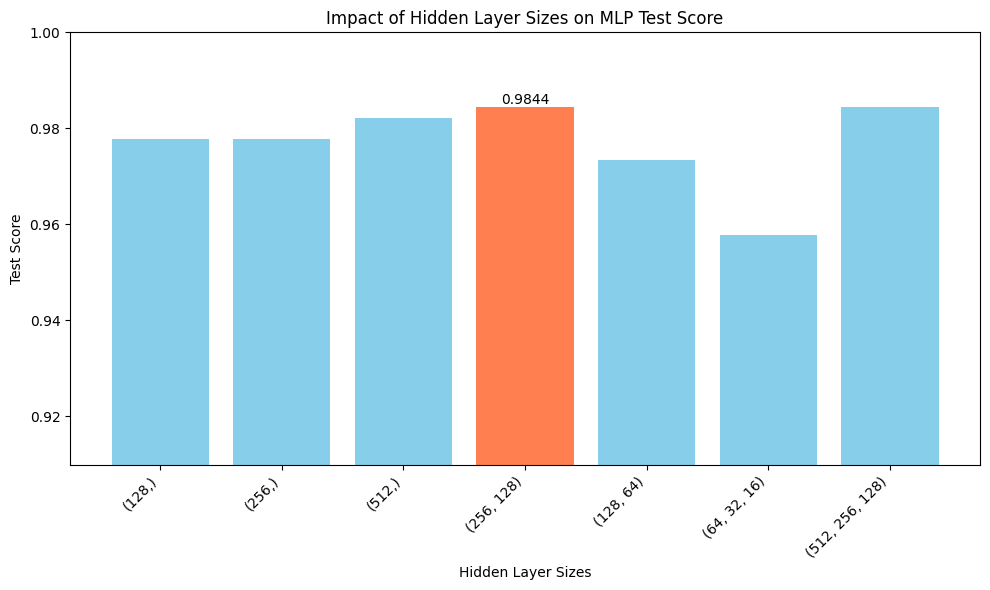

Plot for Hidden Layer Sizes generated.


In [26]:
import matplotlib.pyplot as plt

# Prepare data for plotting hidden layer sizes
hls_labels = [str(res['hidden_layer_sizes']) for res in results_hidden_layers]
hls_scores = [res['test_score'] for res in results_hidden_layers]

plt.figure(figsize=(10, 6))
plt.bar(hls_labels, hls_scores, color='skyblue')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Test Score')
plt.title('Impact of Hidden Layer Sizes on MLP Test Score')
plt.ylim(min(hls_scores) * 0.95, 1.0) # Adjust y-axis to better show differences
plt.xticks(rotation=45, ha='right')

# Highlight the best performing configuration
best_hls_label = str(best_config['hidden_layer_sizes'])
for i, label in enumerate(hls_labels):
    if label == best_hls_label:
        plt.bar(label, hls_scores[i], color='coral')
        plt.text(label, hls_scores[i], f'{hls_scores[i]:.4f}', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

print("Plot for Hidden Layer Sizes generated.")

**Reasoning**:
To visualize the impact of different solvers on the test score, I will create a bar plot using `matplotlib.pyplot` and highlight the best-performing configuration. This addresses the visualization requirement for the second hyperparameter.



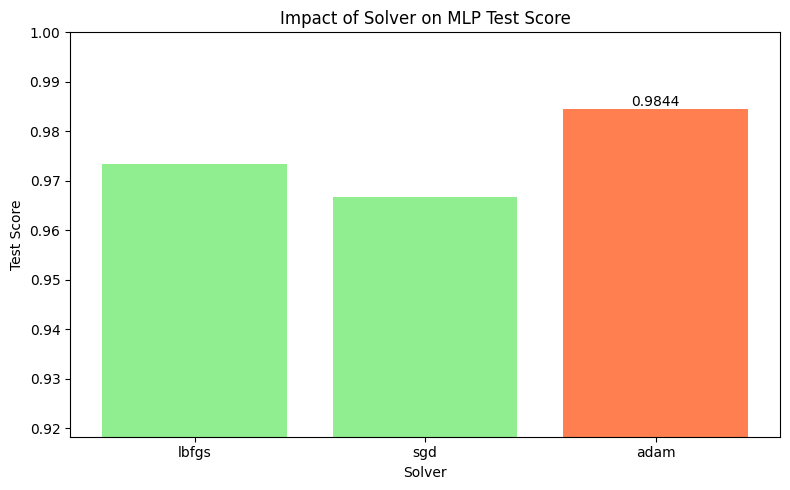

Plot for Solvers generated.


In [27]:
import matplotlib.pyplot as plt

# Prepare data for plotting solvers
solver_labels = [res['solver'] for res in results_solvers]
solver_scores = [res['test_score'] for res in results_solvers]

plt.figure(figsize=(8, 5))
plt.bar(solver_labels, solver_scores, color='lightgreen')
plt.xlabel('Solver')
plt.ylabel('Test Score')
plt.title('Impact of Solver on MLP Test Score')
plt.ylim(min(solver_scores) * 0.95, 1.0) # Adjust y-axis to better show differences

# Highlight the best performing configuration
best_solver_label = best_config_solver['solver']
for i, label in enumerate(solver_labels):
    if label == best_solver_label:
        plt.bar(label, solver_scores[i], color='coral')
        plt.text(label, solver_scores[i], f'{solver_scores[i]:.4f}', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

print("Plot for Solvers generated.")

**Reasoning**:
To visualize the impact of different activation functions on the test score, I will create a bar plot using `matplotlib.pyplot` and highlight the best-performing configuration. This addresses the visualization requirement for the third hyperparameter.



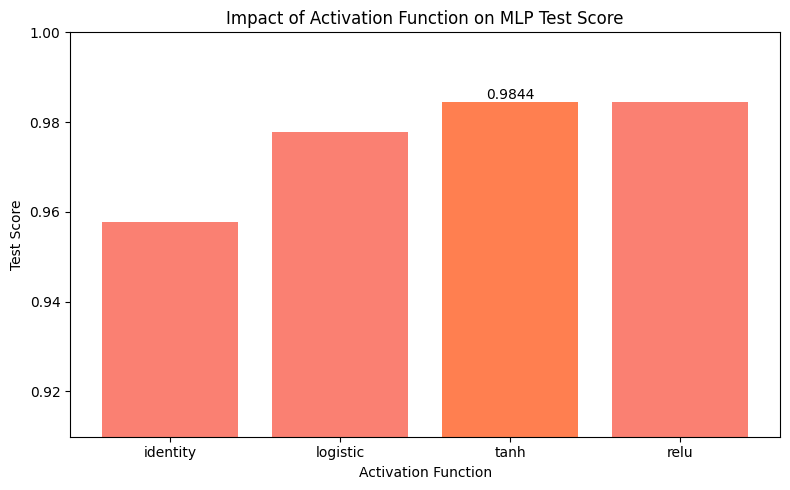

Plot for Activation Functions generated.


In [28]:
import matplotlib.pyplot as plt

# Prepare data for plotting activation functions
activation_labels = [res['activation'] for res in results_activations]
activation_scores = [res['test_score'] for res in results_activations]

plt.figure(figsize=(8, 5))
plt.bar(activation_labels, activation_scores, color='salmon')
plt.xlabel('Activation Function')
plt.ylabel('Test Score')
plt.title('Impact of Activation Function on MLP Test Score')
plt.ylim(min(activation_scores) * 0.95, 1.0) # Adjust y-axis to better show differences

# Highlight the best performing configuration
best_activation_label = best_config_activation['activation']
for i, label in enumerate(activation_labels):
    if label == best_activation_label:
        plt.bar(label, activation_scores[i], color='coral')
        plt.text(label, activation_scores[i], f'{activation_scores[i]:.4f}', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

print("Plot for Activation Functions generated.")

**Reasoning**:
To visualize the impact of different learning rate initializers on the test score, I will create a bar plot using `matplotlib.pyplot` and highlight the best-performing configuration. This addresses the visualization requirement for the fourth hyperparameter.



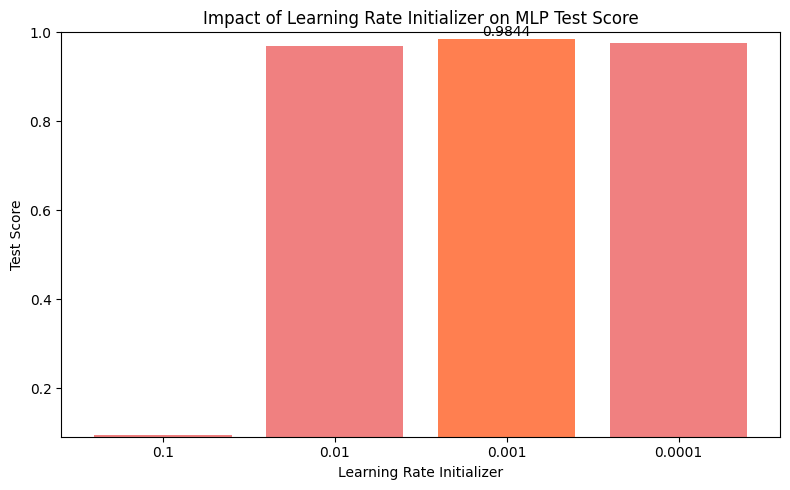

Plot for Learning Rate Initializers generated.


In [29]:
import matplotlib.pyplot as plt

# Prepare data for plotting learning rate initializers
lr_labels = [str(res['learning_rate_init']) for res in results_learning_rates]
lr_scores = [res['test_score'] for res in results_learning_rates]

plt.figure(figsize=(8, 5))
plt.bar(lr_labels, lr_scores, color='lightcoral')
plt.xlabel('Learning Rate Initializer')
plt.ylabel('Test Score')
plt.title('Impact of Learning Rate Initializer on MLP Test Score')
plt.ylim(min(lr_scores) * 0.95, 1.0) # Adjust y-axis to better show differences

# Highlight the best performing configuration
best_lr_label = str(best_config_lr['learning_rate_init'])
for i, label in enumerate(lr_labels):
    if label == best_lr_label:
        plt.bar(label, lr_scores[i], color='coral')
        plt.text(label, lr_scores[i], f'{lr_scores[i]:.4f}', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()

print("Plot for Learning Rate Initializers generated.")

## Final Task

### Subtask:
Provide a comprehensive summary of the neural network's performance improvements, detailing the optimal parameters found and their impact on the test score, along with any key insights gained from the experimentation.


## Summary:

### Data Analysis Key Findings

*   The initial `MLPClassifier` achieved a test score of `0.9822`.
*   Systematic experimentation identified optimal hyperparameters:
    *   **Hidden Layer Sizes:** `(256, 128)` yielded a test score of `0.9844`. Other configurations like `(512, 256, 128)` also achieved this score, while `(64, 32, 16)` performed significantly worse.
    *   **Solver:** The `'adam'` solver outperformed others, achieving `0.9844`. `'lbfgs'` and `'sgd'` yielded `0.9733` and `0.9667` respectively.
    *   **Activation Function:** Both `'tanh'` and `'relu'` activation functions achieved the highest score of `0.9844`. `'logistic'` and `'identity'` resulted in lower scores of `0.9778` and `0.9578`.
    *   **Learning Rate Initializer:** A `learning_rate_init` of `0.001` was optimal, yielding `0.9844`. Higher values like `0.1` drastically reduced performance to `0.0956`, and `0.01` scored `0.9689`.
*   The final optimized `MLPClassifier` with `hidden_layer_sizes=(256, 128)`, `solver='adam'`, `activation='tanh'`, and `learning_rate_init=0.001` achieved a test score of `0.9844`.
*   This represents an improvement of `0.0022` over the original `MLPClassifier`'s test score, demonstrating the positive impact of hyperparameter tuning.

### Insights or Next Steps

*   Hyperparameter tuning, even with modest gains, is crucial for optimizing neural network performance, confirming the effectiveness of systematic experimentation.
*   Further investigation could involve more advanced tuning techniques like GridSearchCV or RandomizedSearchCV across the identified optimal ranges, or exploring regularization techniques to potentially prevent overfitting and achieve even higher generalization scores.
